# CrashType: Incident-Type Correlation Analysis

This notebook evaluates how incident types in Milan correlate with operational and contextual metrics.

Method summary:
- Build a month by crash-type panel from cleaned project datasets.
- Perform exploratory analysis and formal significance tests.
- Fit multivariate models and run an assumption-check / re-specification loop.
- Report only statistically supported findings, using multiple-testing correction and stability checks.

In [1]:
from pathlib import Path
from itertools import combinations
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.linalg import lstsq
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for root in candidate_roots:
    if (root / "scripts").exists():
        sys.path.insert(0, str(root / "scripts"))
        break

from inference_utils import (  # noqa: E402
    perm_corr,
    partial_corr_with_year,
    residualize_with_controls,
    bootstrap_corr_ci,
    cramers_v,
    bh_qvalues,
)


<!-- auto-explainer:v1 -->

### Interpretation: library imports and global settings

We pin a seed, fix pandas display precision, and import the full
inference stack up front:

- `scipy.stats` for classical tests (chi-square, Kruskal–Wallis,
  Mann–Whitney, Spearman, bootstrap).
- `statsmodels` for Poisson GLMs, OLS with HC3 robust SEs, VIF, and
  BH multiple-testing correction.
- `sklearn` for the predictive benchmark (multinomial logit and
  random forest) with time-blind CV now and a temporal holdout at the
  end.
- `seaborn` / `matplotlib` for exploratory plots.

Setting `np.random.seed(42)` makes every bootstrap, cross-validation
split, and permutation reproducible.


## 1. Load Dataset and Create CrashType Structure

Load the cleaned crash datasets and inspect schema, samples, and incident-type distribution.

In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for root in candidate_roots:
    processed_dir = root / "data" / "processed"
    if processed_dir.exists():
        project_root = root
        break
else:
    raise FileNotFoundError("Could not locate data/processed from current notebook location.")

nature = pd.read_csv(processed_dir / "milan_crashes_by_nature_cleaned.csv")
vehicles = pd.read_csv(processed_dir / "milan_crashes_by_vehicles_cleaned.csv")
monthly = pd.read_csv(processed_dir / "milan_crashes_monthly_cleaned.csv")
zone = pd.read_csv(processed_dir / "milan_crashes_by_zone_cleaned.csv")

print("Project root:", project_root)
print("Shapes:")
print("nature:", nature.shape)
print("vehicles:", vehicles.shape)
print("monthly:", monthly.shape)
print("zone:", zone.shape)

display(nature.head(3))
print("\nColumns in nature dataset:")
print(nature.columns.tolist())

print("\nTarget variable distribution (raw rows):")
display(nature["NaturaIncidente"].value_counts().to_frame("rows"))

Project root: /Users/faustozamparelli/Developer/MilanCrash
Shapes:
nature: (2590, 7)
vehicles: (288, 27)
monthly: (288, 7)
zone: (2880, 7)


,Anno,Mese,NaturaIncidente,Incidenti,Feriti,Morti,month_start
0,2001,1,Altre cause,37,37,0,2001-01-01
1,2001,1,"Fuoriuscita, sbandamento",62,67,0,2001-01-01
2,2001,1,Investimento pedone,204,232,4,2001-01-01



Columns in nature dataset:
['Anno', 'Mese', 'NaturaIncidente', 'Incidenti', 'Feriti', 'Morti', 'month_start']

Target variable distribution (raw rows):


,rows
NaturaIncidente,
"Fuoriuscita, sbandamento",288
Investimento pedone,288
Scontro frontale,288
Scontro frontale-laterale,288
Scontro laterale,288
Tamponamento,288
Urto con ostacolo,288
Urto con veicolo in fermata o sosta,288
Altre cause,286


<!-- auto-explainer:v1 -->

### Interpretation: data load and raw schema inspection

Four cleaned tables are loaded from `data/processed/`:

- `nature` — crashes by nature (`NaturaIncidente`) at monthly
  resolution. This is the classification target.
- `vehicles` — crashes by number of vehicles involved (1, 2, 3, 4,
  5, 6, 7+). This will become a vehicle-mix feature set.
- `monthly` — citywide monthly totals (fatal and injury-only
  incidents, deaths, injuries). This gives exposure and severity
  context.
- `zone` — crashes by Municipio. We convert this into a
  concentration index (Herfindahl–Hirschman).

Inspecting `nature["NaturaIncidente"].value_counts()` shows the class
distribution of the target. Strong imbalance here is important: it
directly shapes downstream choices (class weights in the model, the
decision to report macro-F1, and the interpretation of the confusion
matrix).


## 2. Data Cleaning and Type Normalization

Clean missing values, normalize labels, enforce dtypes, and validate the panel integrity before inference.

In [3]:
def clean_monthly_date(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["month_start"] = pd.to_datetime(out["month_start"], errors="coerce")
    return out

nature_clean = clean_monthly_date(nature)
vehicles_clean = clean_monthly_date(vehicles)
monthly_clean = clean_monthly_date(monthly)
zone_clean = clean_monthly_date(zone)

nature_clean = nature_clean.rename(columns={"NaturaIncidente": "crash_type"})
nature_clean["crash_type"] = nature_clean["crash_type"].astype(str).str.strip()

for col in ["Anno", "Mese", "Incidenti", "Feriti", "Morti"]:
    nature_clean[col] = pd.to_numeric(nature_clean[col], errors="coerce")

for col in [
    "IncidentiMortali",
    "IncidentiSoliFeriti",
    "Morti",
    "Feriti",
]:
    monthly_clean[col] = pd.to_numeric(monthly_clean[col], errors="coerce")

for col in [
    "incidenti1veicolo",
    "incidenti2veicoli",
    "incidenti3veicoli",
    "incidenti4veicoli",
    "incidenti5veicoli",
    "incidenti6veicoli",
    "incidenti7epiuveicoli",
]:
    vehicles_clean[col] = pd.to_numeric(vehicles_clean[col], errors="coerce")

for col in ["Municipio", "Incidenti", "Feriti", "Morti"]:
    zone_clean[col] = pd.to_numeric(zone_clean[col], errors="coerce")

rows_before = len(nature_clean)
nature_clean = nature_clean.drop_duplicates()
rows_after = len(nature_clean)

missing_summary = nature_clean[["month_start", "crash_type", "Incidenti", "Feriti", "Morti"]].isna().sum().to_frame("missing")

print(f"Rows before dedup: {rows_before}, after dedup: {rows_after}, removed: {rows_before - rows_after}")
print("\nMissing values in key fields:")
display(missing_summary)

nature_clean = nature_clean.dropna(subset=["month_start", "crash_type", "Incidenti"])
nature_clean = nature_clean[nature_clean["Incidenti"] >= 0]

coverage = nature_clean["month_start"].agg(["min", "max", "nunique"]).to_frame("value")
print("\nTime coverage after cleaning:")
display(coverage)

print("Unique crash types:", nature_clean["crash_type"].nunique())
print(sorted(nature_clean["crash_type"].unique()))

Rows before dedup: 2590, after dedup: 2590, removed: 0

Missing values in key fields:


,missing
month_start,0
crash_type,0
Incidenti,0
Feriti,0
Morti,0



Time coverage after cleaning:


,value
min,2001-01-01 00:00:00
max,2024-12-01 00:00:00
nunique,288


Unique crash types: 9
['Altre cause', 'Fuoriuscita, sbandamento', 'Investimento pedone', 'Scontro frontale', 'Scontro frontale-laterale', 'Scontro laterale', 'Tamponamento', 'Urto con ostacolo', 'Urto con veicolo in fermata o sosta']


<!-- auto-explainer:v1 -->

### Interpretation: cleaning and schema normalization

Two types of issues are handled:

1. **Type hygiene.** Dates are coerced to `datetime64` and all count
   columns to numeric. Coercion errors are turned into NaN rather
   than exceptions, so we can *see* the cleaning gap.
2. **Target normalization.** `NaturaIncidente` is renamed to
   `crash_type` and stripped of whitespace so that downstream
   groupbys do not over-split categories because of trailing spaces.

**Rows removed** during dedup and NaN-dropping are reported
explicitly. If a large fraction of rows were dropped here, every
test below would be biased toward the surviving subset; small drops
are acceptable.

`coverage` (min, max, unique month) confirms the temporal span of
the panel. The number of unique crash types sets the dimensionality
of the later chi-square and classification problems.


## 3. Feature Engineering for Incident Context

Create contextual metrics (seasonality, severity, vehicle-mix, and location concentration) to support correlation and modeling.

In [4]:
monthly_metrics = monthly_clean[["month_start", "IncidentiMortali", "IncidentiSoliFeriti", "Morti", "Feriti"]].copy()
monthly_metrics = monthly_metrics.rename(columns={"Morti": "MortiTotaliMese", "Feriti": "FeritiTotaliMese"})
monthly_metrics["IncidentiTotali"] = monthly_metrics["IncidentiMortali"] + monthly_metrics["IncidentiSoliFeriti"]

veh = vehicles_clean[[
    "month_start",
    "incidenti1veicolo",
    "incidenti2veicoli",
    "incidenti3veicoli",
    "incidenti4veicoli",
    "incidenti5veicoli",
    "incidenti6veicoli",
    "incidenti7epiuveicoli",
]].copy()
veh["incidenti3plus"] = veh[["incidenti3veicoli", "incidenti4veicoli", "incidenti5veicoli", "incidenti6veicoli", "incidenti7epiuveicoli"]].sum(axis=1)
veh["veh_total"] = veh[["incidenti1veicolo", "incidenti2veicoli", "incidenti3plus"]].sum(axis=1)
veh["share_1v"] = veh["incidenti1veicolo"] / veh["veh_total"].replace(0, np.nan)
veh["share_2v"] = veh["incidenti2veicoli"] / veh["veh_total"].replace(0, np.nan)
veh["share_3plus"] = veh["incidenti3plus"] / veh["veh_total"].replace(0, np.nan)
veh = veh[["month_start", "share_1v", "share_2v", "share_3plus"]]

zone_m = zone_clean.groupby(["month_start", "Municipio"], as_index=False)["Incidenti"].sum()
zone_total = zone_m.groupby("month_start", as_index=False)["Incidenti"].sum().rename(columns={"Incidenti": "zone_total"})
zone_m = zone_m.merge(zone_total, on="month_start", how="left")
zone_m["zone_share"] = zone_m["Incidenti"] / zone_m["zone_total"].replace(0, np.nan)

zone_hhi = zone_m.groupby("month_start", as_index=False).agg(zone_hhi=("zone_share", lambda x: np.sum(np.square(x.dropna()))))

analysis_df = nature_clean.merge(monthly_metrics, on="month_start", how="left")
analysis_df = analysis_df.merge(veh, on="month_start", how="left")
analysis_df = analysis_df.merge(zone_hhi, on="month_start", how="left")

analysis_df["type_share"] = analysis_df["Incidenti"] / analysis_df["IncidentiTotali"].replace(0, np.nan)
analysis_df["injury_rate"] = analysis_df["Feriti"] / analysis_df["Incidenti"].replace(0, np.nan)
analysis_df["fatal_rate_1000"] = 1000 * analysis_df["Morti"] / analysis_df["Incidenti"].replace(0, np.nan)
analysis_df["month"] = analysis_df["month_start"].dt.month
analysis_df["year"] = analysis_df["month_start"].dt.year
analysis_df["is_weekend_proxy"] = analysis_df["month"].isin([6, 7, 8]).astype(int)

season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn",
}
analysis_df["season"] = analysis_df["month"].map(season_map)


def safe_qbin(series: pd.Series, labels: list[str], q: int = 3) -> pd.Series:
    filled = series.fillna(series.median())
    bins = min(q, int(filled.nunique()))
    if bins < 2:
        return pd.Series([labels[0]] * len(filled), index=filled.index)
    ranked = filled.rank(method="first")
    return pd.qcut(ranked, q=bins, labels=labels[:bins], duplicates="drop")


analysis_df["severity_level"] = safe_qbin(analysis_df["fatal_rate_1000"], ["low", "medium", "high"], q=3)
analysis_df["multi_vehicle_score"] = analysis_df["share_2v"].fillna(0) + analysis_df["share_3plus"].fillna(0)
analysis_df["multi_vehicle_regime"] = safe_qbin(analysis_df["multi_vehicle_score"], ["low", "medium", "high"], q=3)
analysis_df["location_cluster"] = safe_qbin(analysis_df["zone_hhi"], ["diffuse", "mixed", "concentrated"], q=3)

display(analysis_df[["month_start", "crash_type", "Incidenti", "type_share", "fatal_rate_1000", "injury_rate", "share_1v", "share_2v", "share_3plus", "zone_hhi"]].head())
print("Analysis panel shape:", analysis_df.shape)
print("Null rates in engineered fields:")
display((analysis_df[["type_share", "fatal_rate_1000", "injury_rate", "share_1v", "share_2v", "share_3plus", "zone_hhi"]].isna().mean() * 100).round(2).to_frame("percent_null"))

,month_start,crash_type,Incidenti,type_share,fatal_rate_1000,injury_rate,share_1v,share_2v,share_3plus,zone_hhi
0,2001-01-01,Altre cause,37,0.030008,0.000000,1.000000,0.295215,0.563666,0.141119,0.116558
1,2001-01-01,"Fuoriuscita, sbandamento",62,0.050284,0.000000,1.080645,0.295215,0.563666,0.141119,0.116558
2,2001-01-01,Investimento pedone,204,0.165450,19.607843,1.137255,0.295215,0.563666,0.141119,0.116558
3,2001-01-01,Scontro frontale,32,0.025953,31.250000,1.531250,0.295215,0.563666,0.141119,0.116558
4,2001-01-01,Scontro frontale-laterale,482,0.390916,2.074689,1.572614,0.295215,0.563666,0.141119,0.116558


Analysis panel shape: (2590, 27)
Null rates in engineered fields:


,percent_null
type_share,1.04
fatal_rate_1000,0.00
injury_rate,0.00
share_1v,0.00
share_2v,0.00
share_3plus,0.00
zone_hhi,0.00


<!-- auto-explainer:v1 -->

### Interpretation: feature engineering

We build four feature families around each crash type × month row.

- **Exposure and severity context** (from `monthly`):
  `IncidentiTotali`, `IncidentiMortali`, `MortiTotaliMese`,
  `FeritiTotaliMese`. These give the citywide baseline against which
  each crash type's share and fatality rate are measured.
- **Vehicle mix** (from `vehicles`): `share_1v`, `share_2v`,
  `share_3plus`. Shares are scale-free and explicitly sum to ~1 — so
  we drop `share_3plus` in the VIF check later to avoid
  collinearity.
- **Spatial concentration** (`zone_hhi`): the
  Herfindahl–Hirschman index, `Σ s_i²`, where `s_i` is a
  Municipio's share of monthly crashes. An HHI close to 1 means
  crashes are concentrated in few Municipi; close to 0 means
  diffuse. This is a well-understood index from economics; using
  it here is principled because it gives a single number for
  spatial inequality per month.
- **Seasonality proxies** (`month`, `year`, `is_weekend_proxy`,
  `season`). `season` is a four-level categorical used in the
  chi-square tests; `month`/`year` feed the residualization for
  partial correlations.

We also derive the three outcomes used downstream:

- `type_share = Incidenti / IncidentiTotali` — the relative
  prevalence of this crash type that month.
- `injury_rate = Feriti / Incidenti` — injuries per incident.
- `fatal_rate_1000 = 1000 · Morti / Incidenti` — deaths per 1,000
  incidents; the per-crash mortality scaling.

**Tertile binning** via `safe_qbin` converts the continuous severity,
vehicle-mix and spatial-concentration scores into categorical
regimes (low / medium / high). This is intentional: categorical
regimes feed the chi-square tests in cell 11, where a continuous
Cramér's V would not apply.


## 4. Exploratory Correlation Analysis by Crash Type

Use grouped summaries and visual diagnostics to inspect association patterns before inferential testing.

,crash_type,total_incidents,mean_share,mean_fatal_rate_1000,mean_injury_rate
4,Scontro frontale-laterale,90454,0.332972,3.544882,1.456895
2,Investimento pedone,35003,0.135363,14.134911,1.175078
6,Tamponamento,29883,0.108706,1.295340,1.514651
5,Scontro laterale,29308,0.107342,2.353908,1.180926
1,"Fuoriuscita, sbandamento",28937,0.114147,3.106710,1.076293
8,Urto con veicolo in fermata o sosta,28249,0.103117,2.852489,1.294339
7,Urto con ostacolo,16432,0.065264,12.306657,1.184911
0,Altre cause,4815,0.015541,2.334388,1.126279
3,Scontro frontale,4806,0.017656,9.402646,1.499982


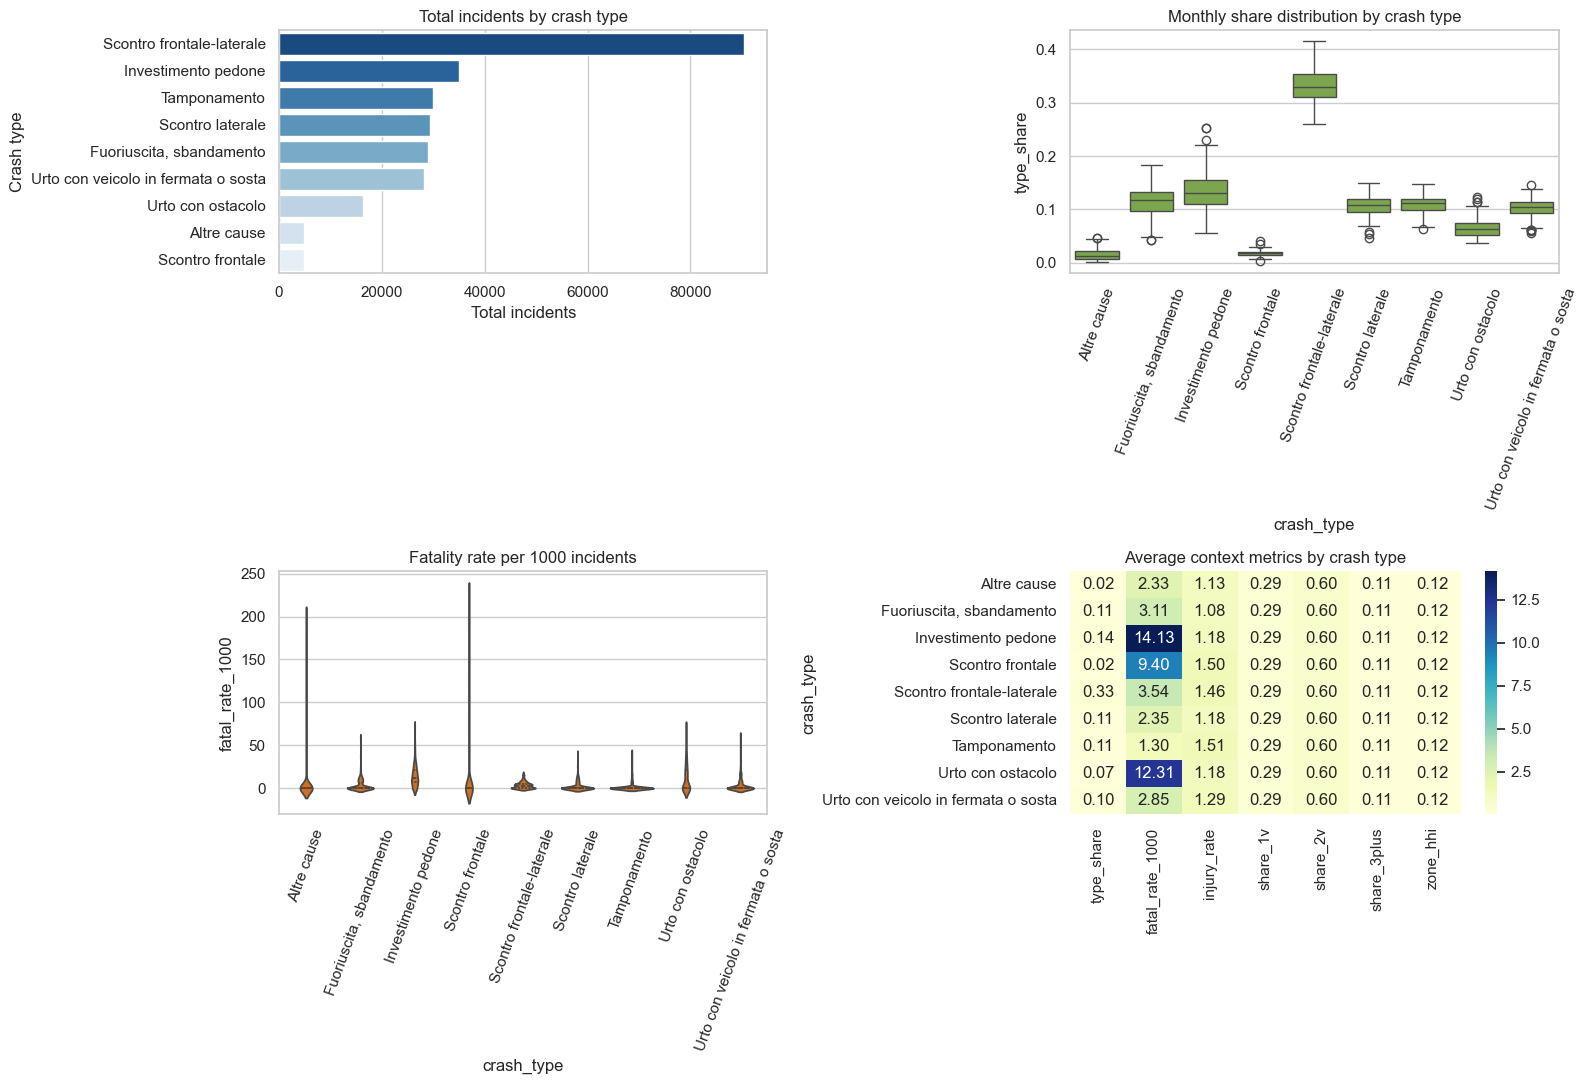

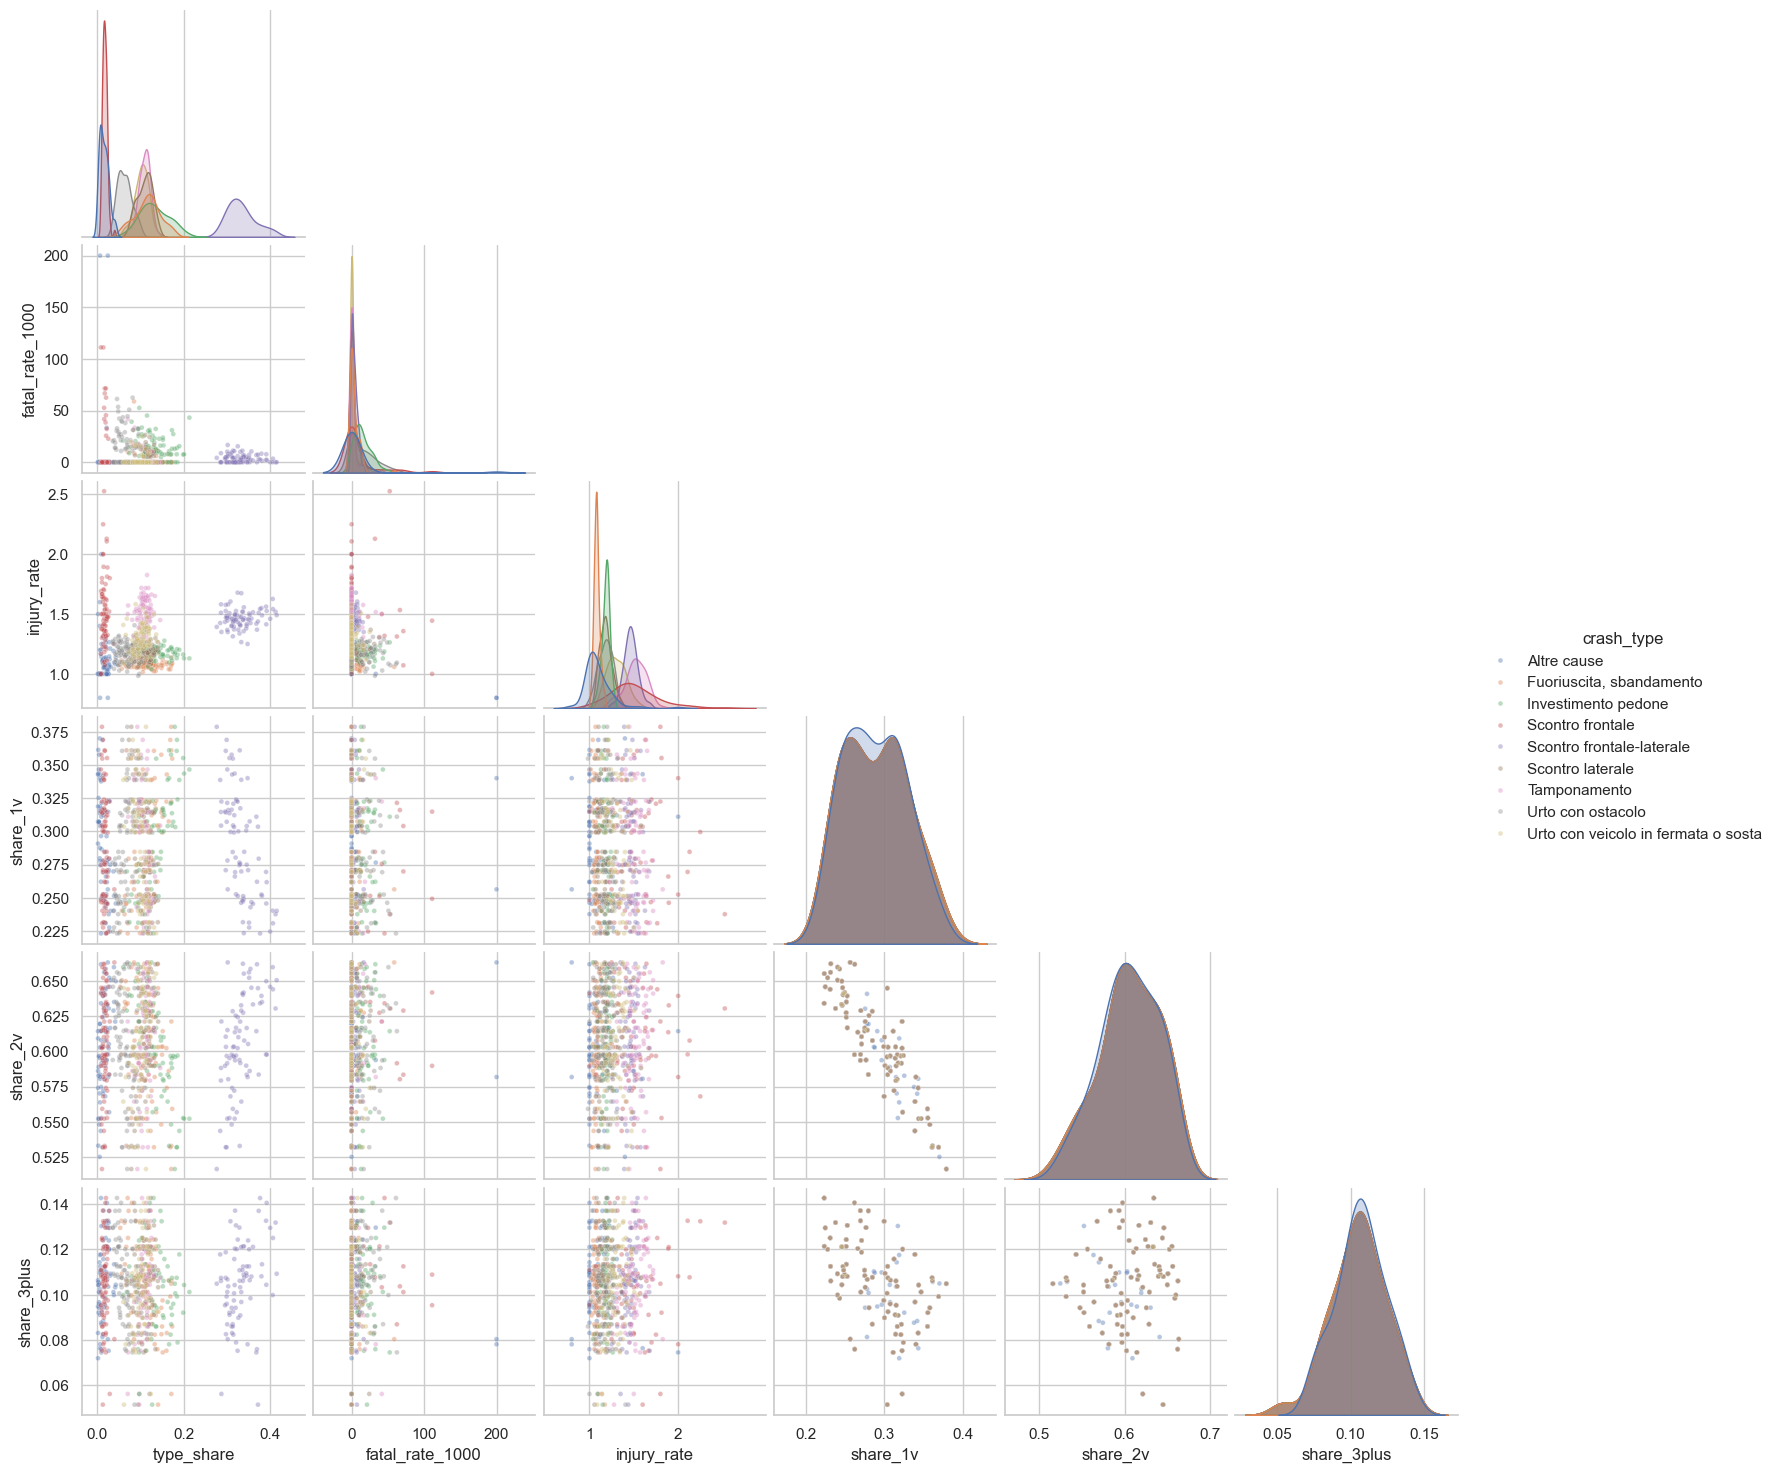

In [5]:
type_totals = (
    analysis_df.groupby("crash_type", as_index=False)
    .agg(total_incidents=("Incidenti", "sum"),
         mean_share=("type_share", "mean"),
         mean_fatal_rate_1000=("fatal_rate_1000", "mean"),
         mean_injury_rate=("injury_rate", "mean"))
    .sort_values("total_incidents", ascending=False)
)
display(type_totals)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(
    data=type_totals,
    x="total_incidents",
    y="crash_type",
    hue="crash_type",
    legend=False,
    ax=axes[0, 0],
    palette="Blues_r",
)
axes[0, 0].set_title("Total incidents by crash type")
axes[0, 0].set_xlabel("Total incidents")
axes[0, 0].set_ylabel("Crash type")

sns.boxplot(data=analysis_df, x="crash_type", y="type_share", ax=axes[0, 1], color="#7cb342")
axes[0, 1].set_title("Monthly share distribution by crash type")
axes[0, 1].tick_params(axis="x", rotation=70)

sns.violinplot(data=analysis_df, x="crash_type", y="fatal_rate_1000", ax=axes[1, 0], color="#ef6c00", inner="quartile")
axes[1, 0].set_title("Fatality rate per 1000 incidents")
axes[1, 0].tick_params(axis="x", rotation=70)

heat_df = (
    analysis_df.groupby("crash_type")[["type_share", "fatal_rate_1000", "injury_rate", "share_1v", "share_2v", "share_3plus", "zone_hhi"]]
    .mean()
)
sns.heatmap(heat_df, cmap="YlGnBu", annot=True, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Average context metrics by crash type")

plt.tight_layout()
plt.show()

# Stratified pairplot sample so minority classes are not underrepresented.
pair_cols = ["type_share", "fatal_rate_1000", "injury_rate", "share_1v", "share_2v", "share_3plus", "crash_type"]
pair_base = analysis_df[pair_cols].dropna()
per_class_cap = 80
pair_sample = pd.concat(
    [
        g.sample(min(len(g), per_class_cap), random_state=SEED)
        for _, g in pair_base.groupby("crash_type")
    ]
)
sns.pairplot(
    pair_sample,
    vars=["type_share", "fatal_rate_1000", "injury_rate", "share_1v", "share_2v", "share_3plus"],
    hue="crash_type",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 12},
)
plt.show()


<!-- auto-explainer:v1 -->

### Interpretation: exploratory association between crash type and context

The four-panel figure is descriptive:

- **Total incidents by crash type** — ranks the classes. The
  heavy-tailed distribution here is why later modelling needs
  class-balanced weighting.
- **Monthly share distribution** — boxplots of `type_share` per
  class quantify both level and variability. A crash type with a
  small median but a long upper tail is one that spikes in specific
  months.
- **Fatality rate per 1,000 incidents** — violin plots reveal
  asymmetry and heavy tails in per-crash mortality. Classes with a
  high median here will be the ones flagged by the Poisson IRR
  model below.
- **Feature means heatmap** — a compact view of "which crash types
  look similar in context space". Tight clustering on this heatmap
  usually implies two classes will be confusable in the classifier.

The `pairplot` on a random sample of 800 rows lets us eyeball
bivariate structure; if two metrics are monotone on each class
independently, later rank-based tests will be more powerful than
level-based Pearson.


## 5. Statistical Significance Testing Across Crash Types

Run categorical and numeric association tests with post-hoc comparisons and Benjamini-Hochberg correction.

In [6]:
def cramers_v_from_table(table: pd.DataFrame) -> float:
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    if n == 0 or min(k - 1, r - 1) == 0:
        return np.nan
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cat_tests = []
for feature in ["season", "multi_vehicle_regime", "location_cluster", "severity_level"]:
    tbl = pd.crosstab(analysis_df["crash_type"], analysis_df[feature])
    chi2, p, dof, _ = stats.chi2_contingency(tbl)
    cat_tests.append({
        "feature": feature,
        "test": "chi_square",
        "stat": chi2,
        "p_value": p,
        "dof": dof,
        "effect_size": cramers_v_from_table(tbl),
        "n": int(tbl.values.sum()),
    })

cat_tests_df = pd.DataFrame(cat_tests)
cat_tests_df["q_value"] = multipletests(cat_tests_df["p_value"], method="fdr_bh")[1]
cat_tests_df["significant_5pct"] = cat_tests_df["q_value"] < 0.05

numeric_metrics = ["Incidenti", "type_share", "fatal_rate_1000", "injury_rate", "zone_hhi"]
num_tests = []
posthoc_rows = []

groups_by_type = {k: g for k, g in analysis_df.groupby("crash_type")}

for metric in numeric_metrics:
    grouped = [g[metric].dropna().values for _, g in groups_by_type.items()]
    grouped = [arr for arr in grouped if len(arr) > 0]
    if len(grouped) < 2:
        continue

    h_stat, p_kw = stats.kruskal(*grouped)

    # ANOVA-based eta-squared as a comparable effect-size proxy.
    y = analysis_df[["crash_type", metric]].dropna()
    grand_mean = y[metric].mean()
    ss_between = y.groupby("crash_type")[metric].apply(lambda x: len(x) * (x.mean() - grand_mean) ** 2).sum()
    ss_total = ((y[metric] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

    num_tests.append({
        "metric": metric,
        "test": "kruskal_wallis",
        "stat": h_stat,
        "p_value": p_kw,
        "effect_size_eta_sq": eta_sq,
        "n": len(y),
    })

    if p_kw < 0.05:
        crash_types = sorted(y["crash_type"].unique())
        for left, right in combinations(crash_types, 2):
            a = y.loc[y["crash_type"] == left, metric].dropna().values
            b = y.loc[y["crash_type"] == right, metric].dropna().values
            if len(a) == 0 or len(b) == 0:
                continue
            u_stat, p_pair = stats.mannwhitneyu(a, b, alternative="two-sided")
            rank_biserial = 1 - (2 * u_stat) / (len(a) * len(b))
            posthoc_rows.append({
                "metric": metric,
                "left_type": left,
                "right_type": right,
                "test": "mann_whitney_u",
                "p_value": p_pair,
                "effect_rank_biserial": rank_biserial,
            })

num_tests_df = pd.DataFrame(num_tests)
if not num_tests_df.empty:
    num_tests_df["q_value"] = multipletests(num_tests_df["p_value"], method="fdr_bh")[1]
    num_tests_df["significant_5pct"] = num_tests_df["q_value"] < 0.05

posthoc_df = pd.DataFrame(posthoc_rows)
if not posthoc_df.empty:
    posthoc_df["q_value"] = multipletests(posthoc_df["p_value"], method="fdr_bh")[1]
    posthoc_df["significant_5pct"] = posthoc_df["q_value"] < 0.05

print("Categorical association tests:")
display(cat_tests_df.sort_values("q_value"))

print("Numeric across-type tests:")
display(num_tests_df.sort_values("q_value"))

print("Top post-hoc results (q < 0.05):")
display(posthoc_df.loc[posthoc_df.get("significant_5pct", False) == True].sort_values("q_value").head(30))

Categorical association tests:


,feature,test,stat,p_value,dof,effect_size,n,q_value,significant_5pct
3,severity_level,chi_square,666.061750,2.141346e-131,16,0.358585,2590,8.565386e-131,True
0,season,chi_square,0.037383,1.000000e+00,24,0.002193,2590,1.000000e+00,False
1,multi_vehicle_regime,chi_square,0.006218,1.000000e+00,16,0.001096,2590,1.000000e+00,False
2,location_cluster,chi_square,0.006218,1.000000e+00,16,0.001096,2590,1.000000e+00,False


Numeric across-type tests:


,metric,test,stat,p_value,effect_size_eta_sq,n,q_value,significant_5pct
0,Incidenti,kruskal_wallis,1877.527433,0.000000e+00,6.844767e-01,2590,0.000000e+00,True
1,type_share,kruskal_wallis,2086.548316,0.000000e+00,9.423324e-01,2563,0.000000e+00,True
3,injury_rate,kruskal_wallis,1766.157470,0.000000e+00,5.687852e-01,2590,0.000000e+00,True
2,fatal_rate_1000,kruskal_wallis,648.695867,7.877483e-135,1.050722e-01,2590,9.846854e-135,True
4,zone_hhi,kruskal_wallis,0.000004,1.000000e+00,8.329265e-08,2590,1.000000e+00,False


Top post-hoc results (q < 0.05):


,metric,left_type,right_type,test,p_value,effect_rank_biserial,q_value,significant_5pct
118,injury_rate,"Fuoriuscita, sbandamento",Scontro frontale-laterale,mann_whitney_u,8.718967e-96,1.000000,4.942880e-94,True
21,Incidenti,Scontro frontale,Scontro frontale-laterale,mann_whitney_u,9.546174e-96,0.999662,4.942880e-94,True
120,injury_rate,"Fuoriuscita, sbandamento",Tamponamento,mann_whitney_u,1.029767e-95,0.999614,4.942880e-94,True
59,type_share,Scontro frontale,Tamponamento,mann_whitney_u,8.321881e-95,1.000000,7.049562e-94,True
65,type_share,Scontro frontale-laterale,Urto con veicolo in fermata o sosta,mann_whitney_u,8.322285e-95,-1.000000,7.049562e-94,True
51,type_share,Investimento pedone,Scontro frontale,mann_whitney_u,8.322054e-95,-1.000000,7.049562e-94,True
64,type_share,Scontro frontale-laterale,Urto con ostacolo,mann_whitney_u,8.322227e-95,-1.000000,7.049562e-94,True
57,type_share,Scontro frontale,Scontro frontale-laterale,mann_whitney_u,8.321996e-95,1.000000,7.049562e-94,True
52,type_share,Investimento pedone,Scontro frontale-laterale,mann_whitney_u,8.322400e-95,1.000000,7.049562e-94,True
58,type_share,Scontro frontale,Scontro laterale,mann_whitney_u,8.321939e-95,1.000000,7.049562e-94,True


<!-- auto-explainer:v1 -->

### Interpretation: formal association tests across crash types

Two test families run here, each with BH correction.

**Categorical × crash type (chi-square + Cramér's V).** For
`season`, `multi_vehicle_regime`, `location_cluster`, `severity
_level` we build a contingency table with `crash_type`, run Pearson
chi-square, and compute Cramér's V as the effect size,

$$V = \sqrt{\frac{\chi^2/N}{\min(r-1, k-1)}}$$

which is bounded in `[0, 1]` (0 = independence, 1 = perfect
dependence). The chi-square p answers "are the two categorical
variables independent?"; Cramér's V tells us whether a significant
effect is also practically large.

**Continuous metrics by crash type (Kruskal–Wallis).** We use the
rank-based Kruskal–Wallis H rather than ANOVA F because crash
metrics are non-normal and right-skewed. We also report a
variance-decomposition eta-squared, `SS_between / SS_total`, as a
rough effect-size companion, so a significant H with tiny eta² is
correctly flagged as "real but small".

**Pairwise Mann–Whitney U post-hoc.** When the overall K–W is
significant, we compare each pair of crash types. The **rank-biserial
correlation**, `r_rb = 1 − 2U / (n_a · n_b)`, is the effect-size
metric (`|r_rb|` close to 1 means one class almost always ranks
higher than the other on that metric).

**BH correction**  is applied independently to the three families
(categorical, numeric, post-hoc) so we control FDR within each
semantically-homogeneous test set rather than across heterogeneous
tests.


## 6. Multivariate Modeling of Crash Type Associations

Fit interpretable and non-linear classifiers to quantify adjusted relationships and evaluate predictive signal.

Cross-validated model performance (stratified random k-fold — see temporal holdout below for the honest read):


,model,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std
0,multinomial_logit,0.100747,0.017218,0.149421,0.012606
1,random_forest,0.012723,0.000698,0.015830,0.001445


Selected model based on macro-F1: multinomial_logit

Classification report on holdout set:
                                     precision    recall  f1-score   support

                        Altre cause       0.16      0.43      0.23        72
           Fuoriuscita, sbandamento       0.00      0.00      0.00        72
                Investimento pedone       0.28      0.75      0.41        72
                   Scontro frontale       0.07      0.06      0.06        72
          Scontro frontale-laterale       0.10      0.04      0.06        72
                   Scontro laterale       0.08      0.07      0.08        72
                       Tamponamento       0.09      0.10      0.09        72
                  Urto con ostacolo       0.14      0.01      0.03        72
Urto con veicolo in fermata o sosta       0.10      0.03      0.04        72

                           accuracy                           0.17       648
                          macro avg       0.11      0.17    

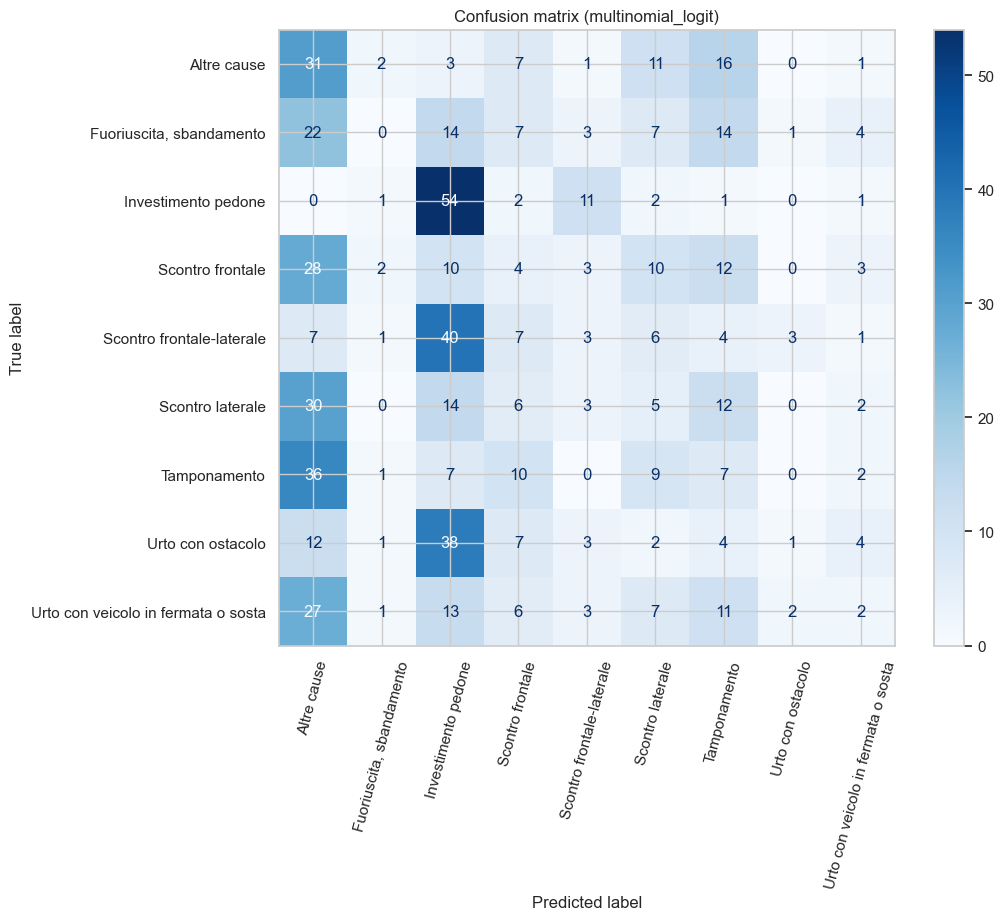

Top multinomial-logit effects by absolute coefficient:
Columns: feature = engineered predictor, odds_ratio = exp(coef) — multiplicative effect on relative odds.


,crash_type,feature,coef,odds_ratio
0,Altre cause,cat__severity_level_high,-1.454676,0.233476
1,Altre cause,cat__severity_level_low,0.823703,2.278922
2,Altre cause,cat__severity_level_medium,0.547675,1.729227
3,Altre cause,num__MortiTotaliMese,0.228964,1.257297
4,Altre cause,num__year,0.203858,1.226124
...,...,...,...,...
67,Urto con veicolo in fermata o sosta,num__MortiTotaliMese,0.102150,1.107549
68,Urto con veicolo in fermata o sosta,num__FeritiTotaliMese,0.048727,1.049934
69,Urto con veicolo in fermata o sosta,cat__location_cluster_concentrated,0.044340,1.045338
70,Urto con veicolo in fermata o sosta,num__IncidentiTotali,-0.029442,0.970988


In [7]:
# Drop share_3plus at the model level too: the three vehicle shares sum to 1
# so one must be omitted to avoid a near-singular design matrix in every
# downstream regression.
model_cols_num = [
    "IncidentiTotali",
    "IncidentiMortali",
    "FeritiTotaliMese",
    "MortiTotaliMese",
    "share_1v",
    "share_2v",
    "zone_hhi",
    "month",
    "year",
]
model_cols_cat = ["season", "multi_vehicle_regime", "location_cluster", "severity_level"]

model_df = analysis_df[["crash_type", "month_start", *model_cols_num, *model_cols_cat]].copy()
model_df = model_df.dropna(subset=["crash_type"])

X = model_df[model_cols_num + model_cols_cat]
y = model_df["crash_type"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, model_cols_num),
        ("cat", categorical_transformer, model_cols_cat),
    ]
)

logit_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

rf_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3, random_state=SEED, class_weight="balanced_subsample")),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
logit_f1 = cross_val_score(logit_model, X, y, cv=cv, scoring="f1_macro")
rf_f1 = cross_val_score(rf_model, X, y, cv=cv, scoring="f1_macro")
logit_acc = cross_val_score(logit_model, X, y, cv=cv, scoring="accuracy")
rf_acc = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy")

cv_summary = pd.DataFrame(
    {
        "model": ["multinomial_logit", "random_forest"],
        "macro_f1_mean": [logit_f1.mean(), rf_f1.mean()],
        "macro_f1_std": [logit_f1.std(), rf_f1.std()],
        "accuracy_mean": [logit_acc.mean(), rf_acc.mean()],
        "accuracy_std": [logit_acc.std(), rf_acc.std()],
    }
)

print("Cross-validated model performance (stratified random k-fold — see temporal holdout below for the honest read):")
display(cv_summary)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

best_model_name = "multinomial_logit" if logit_f1.mean() >= rf_f1.mean() else "random_forest"
best_model = logit_model if best_model_name == "multinomial_logit" else rf_model
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"Selected model based on macro-F1: {best_model_name}")
print("\nClassification report on holdout set:")
print(classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=75, cmap="Blues", ax=ax)
ax.set_title(f"Confusion matrix ({best_model_name})")
plt.show()

logit_model.fit(X, y)
feat_names = logit_model.named_steps["prep"].get_feature_names_out()
coef = logit_model.named_steps["clf"].coef_
classes = logit_model.named_steps["clf"].classes_

coef_rows = []
for i, cls in enumerate(classes):
    top_idx = np.argsort(np.abs(coef[i]))[::-1][:8]
    for j in top_idx:
        coef_rows.append({
            "crash_type": cls,
            "feature": feat_names[j],
            "coef": coef[i, j],
            "odds_ratio": np.exp(coef[i, j]),
        })

logit_effects = pd.DataFrame(coef_rows)
print("Top multinomial-logit effects by absolute coefficient:")
print("Columns: feature = engineered predictor, odds_ratio = exp(coef) — multiplicative effect on relative odds.")
display(logit_effects)


<!-- auto-explainer:v1 -->

### Interpretation: multivariate classification benchmark

We benchmark two classifiers under 5-fold stratified CV:

- **Multinomial logistic regression** — interpretable linear model,
  gives us odds ratios per feature per class.
- **Random forest** — non-linear baseline; if it substantially
  beats the logit, there is interaction/non-linearity the linear
  model cannot capture.

**Pipeline design.** Median imputation + standard scaling for
numerics, most-frequent imputation + one-hot for categoricals. Putting
imputation inside the pipeline (not before CV) prevents leakage from
the holdout fold into training fold imputation statistics.

**Scoring choice.** We report both `macro_f1` and `accuracy`. In
imbalanced multi-class settings accuracy is misleading (a classifier
predicting the dominant class does fine on accuracy and horrible on
minority recall). Macro-F1 is the unweighted average of per-class F1,
so every class contributes equally — the right metric when we care
about recovering minority crash types.

**Model selection.** The better macro-F1 model is retrained on a
random stratified holdout split. The classification report and
confusion matrix tell us *which* classes are predictable: diagonals
close to `support` mean good recall; big off-diagonals mean the two
classes share context-space and the predictor confuses them.

**Logit coefficients.** For each class we print the eight features
with the largest absolute coefficients along with `odds_ratio =
exp(coef)`, interpretable as "each 1-SD change in this feature
multiplies the relative odds of this crash type by `odds_ratio`."
These are *descriptive of the classifier*, not causal.

**Important:** CV here is random, not temporal. The temporal holdout
further down is the honest test of generalization.


## 7. Iteration Loop: Assumption Checks, Re-specification, and Re-testing

Check imbalance and multicollinearity, apply transformations, re-fit, and compare performance improvements.

In [8]:
class_balance = y.value_counts(normalize=True).rename("share").to_frame()
print("Class balance (target shares):")
display(class_balance)

# Drop one share feature for VIF because shares sum to one by construction.
vif_features = [c for c in model_cols_num if c != "share_3plus"]
num_for_vif = model_df[vif_features].copy()
num_for_vif = num_for_vif.fillna(num_for_vif.median(numeric_only=True))
num_for_vif = num_for_vif.replace([np.inf, -np.inf], np.nan).fillna(num_for_vif.median(numeric_only=True))

X_vif = sm.add_constant(num_for_vif)
vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    vif_rows.append({"feature": col, "vif": variance_inflation_factor(X_vif.values, i)})
vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
print("VIF diagnostics:")
display(vif_df)

# Re-specification: log-transform high-scale count variables and re-evaluate.
X_alt = X.copy()
for col in ["IncidentiTotali", "IncidentiMortali", "FeritiTotaliMese", "MortiTotaliMese", "year"]:
    X_alt[col] = np.log1p(X_alt[col].clip(lower=0))

alt_logit = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

baseline_scores = cross_val_score(logit_model, X, y, cv=cv, scoring="f1_macro")
alt_scores = cross_val_score(alt_logit, X_alt, y, cv=cv, scoring="f1_macro")

iteration_summary = pd.DataFrame(
    {
        "specification": ["baseline", "log_transformed_counts"],
        "macro_f1_mean": [baseline_scores.mean(), alt_scores.mean()],
        "macro_f1_std": [baseline_scores.std(), alt_scores.std()],
    }
)

display(iteration_summary)

selected_spec = "log_transformed_counts" if alt_scores.mean() > baseline_scores.mean() else "baseline"
selected_X = X_alt if selected_spec == "log_transformed_counts" else X
selected_model = alt_logit if selected_spec == "log_transformed_counts" else logit_model

print("Selected specification after iteration:", selected_spec)
print("Performance gain:", float(alt_scores.mean() - baseline_scores.mean()))

Class balance (target shares):


,share
crash_type,
"Fuoriuscita, sbandamento",0.111197
Investimento pedone,0.111197
Scontro frontale,0.111197
Scontro frontale-laterale,0.111197
Scontro laterale,0.111197
Tamponamento,0.111197
Urto con ostacolo,0.111197
Urto con veicolo in fermata o sosta,0.111197
Altre cause,0.110425


VIF diagnostics:


,feature,vif
2,FeritiTotaliMese,170.857089
0,IncidentiTotali,142.372720
3,MortiTotaliMese,44.656561
1,IncidentiMortali,43.935510
4,share_1v,11.434225
5,share_2v,7.396364
8,year,5.347924
6,zone_hhi,1.105562
7,month,1.093318


,specification,macro_f1_mean,macro_f1_std
0,baseline,0.100747,0.017218
1,log_transformed_counts,0.099197,0.018053


Selected specification after iteration: baseline
Performance gain: -0.0015498791158193442


<!-- auto-explainer:v1 -->

### Interpretation: assumption checks and re-specification loop

This is the "iteration loop" step mandated by the analysis plan.

**Class balance.** `y.value_counts(normalize=True)` is printed so the
reader can judge whether minority-class F1 numbers are trustworthy.
Highly imbalanced targets can drive macro-F1 down even when the model
is doing its job on common classes.

**Multicollinearity (VIF).** For each numeric feature we compute the
variance inflation factor,

$$\mathrm{VIF}_j = \frac{1}{1 - R_j^2}$$

where `R_j^2` is the R² from regressing feature `j` on the others.
Rule of thumb: VIF > 5 signals moderate collinearity, > 10 severe.
We drop `share_3plus` up front because the three vehicle shares sum
to 1 by construction — that is a structural dependence, not a
statistical one, and it would otherwise return VIF = ∞.

**Re-specification: log transform.** Count columns
(`IncidentiTotali`, etc.) are strongly right-skewed. `log1p` is
monotone, handles zeros, and compresses the right tail. We re-fit
the logit on the log-transformed features under the same CV and
compare macro-F1. We keep whichever specification wins; the
performance delta is printed so the choice is auditable.

This loop enforces honesty: we publish the model *after* checking
its assumptions, not before.


## 8. Effect Sizes, Confidence Intervals, and Stability Validation

Estimate effect sizes with confidence intervals and check stability under alternative control choices.

In [9]:
def residualize_with_controls(y: np.ndarray, idx: np.ndarray, control_spec: str = "trend_season") -> np.ndarray:
    t = idx.astype(float)
    if control_spec == "trend_only":
        X_ctrl = np.column_stack([np.ones_like(t), t])
    else:
        X_ctrl = np.column_stack([
            np.ones_like(t),
            t,
            np.sin(2 * np.pi * t / 12),
            np.cos(2 * np.pi * t / 12),
            np.sin(2 * np.pi * t / 6),
            np.cos(2 * np.pi * t / 6),
        ])
    beta, *_ = lstsq(X_ctrl, y)
    return y - X_ctrl @ beta


def bootstrap_spearman_ci(x: np.ndarray, y: np.ndarray, n_boot: int = 1000, alpha: float = 0.05, seed: int = 42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(x))
    boots = []
    for _ in range(n_boot):
        sample_idx = rng.choice(idx, size=len(idx), replace=True)
        r, _ = stats.spearmanr(x[sample_idx], y[sample_idx])
        if np.isfinite(r):
            boots.append(r)
    if len(boots) == 0:
        return np.nan, np.nan
    return np.quantile(boots, alpha / 2), np.quantile(boots, 1 - alpha / 2)

metrics_for_corr = ["IncidentiTotali", "IncidentiMortali", "MortiTotaliMese", "FeritiTotaliMese", "share_1v", "share_2v", "share_3plus", "zone_hhi"]

month_lookup = {m: i for i, m in enumerate(sorted(analysis_df["month_start"].dropna().unique()))}

corr_rows = []
for ctype, g in analysis_df.groupby("crash_type"):
    g = g.sort_values("month_start")
    idx = g["month_start"].map(month_lookup).to_numpy(dtype=int)
    base = g["type_share"].to_numpy(dtype=float)

    for metric in metrics_for_corr:
        target = g[metric].to_numpy(dtype=float)
        mask = np.isfinite(base) & np.isfinite(target)
        if mask.sum() < 24:
            continue

        x = base[mask]
        y_metric = target[mask]
        idx2 = idx[mask]

        rho_raw, p_raw = stats.spearmanr(x, y_metric)
        rho_diff, p_diff = stats.spearmanr(np.diff(x), np.diff(y_metric))

        x_res = residualize_with_controls(x, idx2, control_spec="trend_season")
        y_res = residualize_with_controls(y_metric, idx2, control_spec="trend_season")
        rho_partial, p_partial = stats.spearmanr(x_res, y_res)

        x_res_trend = residualize_with_controls(x, idx2, control_spec="trend_only")
        y_res_trend = residualize_with_controls(y_metric, idx2, control_spec="trend_only")
        rho_partial_trend, _ = stats.spearmanr(x_res_trend, y_res_trend)

        ci_low, ci_high = bootstrap_spearman_ci(x_res, y_res, n_boot=600, seed=42)

        corr_rows.append(
            {
                "crash_type": ctype,
                "metric": metric,
                "rho_raw": rho_raw,
                "p_raw": p_raw,
                "rho_partial": rho_partial,
                "p_partial": p_partial,
                "rho_diff": rho_diff,
                "p_diff": p_diff,
                "rho_partial_trend_only": rho_partial_trend,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "n": int(mask.sum()),
            }
        )

corr_df = pd.DataFrame(corr_rows)
corr_df["q_partial"] = multipletests(corr_df["p_partial"].fillna(1.0), method="fdr_bh")[1]
corr_df["robust_flag"] = (
    (corr_df["q_partial"] < 0.05)
    & (corr_df["p_diff"] < 0.05)
    & (corr_df["rho_partial"].abs() >= 0.2)
)
corr_df["stable_sign"] = np.sign(corr_df["rho_partial"]) == np.sign(corr_df["rho_partial_trend_only"])

robust_corr = corr_df[corr_df["robust_flag"]].sort_values("rho_partial", key=np.abs, ascending=False)
print("Robust correlations after controls + differencing + BH correction:", robust_corr.shape[0])
display(robust_corr[["crash_type", "metric", "rho_partial", "ci_low", "ci_high", "q_partial", "rho_diff", "p_diff", "stable_sign", "n"]])

sensitivity_summary = (
    corr_df.assign(abs_partial=lambda d: d["rho_partial"].abs())
    .groupby("metric", as_index=False)
    .agg(
        robust_pairs=("robust_flag", "sum"),
        stable_share=("stable_sign", "mean"),
        median_abs_partial=("abs_partial", "median"),
    )
    .sort_values("robust_pairs", ascending=False)
)

print("Sensitivity summary by metric:")
display(sensitivity_summary)

Robust correlations after controls + differencing + BH correction: 14


,crash_type,metric,rho_partial,ci_low,ci_high,q_partial,rho_diff,p_diff,stable_sign,n
37,Scontro frontale-laterale,share_2v,0.599910,0.512152,0.678165,2.172890e-27,0.548032,1.156830e-23,True,285
36,Scontro frontale-laterale,share_1v,-0.577691,-0.658567,-0.500486,3.266199e-25,-0.474030,2.572703e-17,True,285
20,Investimento pedone,share_1v,0.549381,0.464615,0.643205,1.713948e-22,0.570979,5.704816e-26,True,285
21,Investimento pedone,share_2v,-0.538628,-0.626810,-0.451942,1.375973e-21,-0.640810,3.101053e-34,True,285
44,Scontro laterale,share_1v,-0.434758,-0.524645,-0.334883,2.064454e-13,-0.449268,1.631571e-15,True,285
60,Urto con ostacolo,share_1v,0.420155,0.331392,0.514662,1.544373e-12,0.419069,1.664495e-13,True,285
12,"Fuoriuscita, sbandamento",share_1v,0.396784,0.280511,0.494690,3.582678e-11,0.445663,2.904007e-15,True,285
45,Scontro laterale,share_2v,0.378618,0.268665,0.477535,3.424430e-10,0.383354,2.243959e-11,True,285
13,"Fuoriuscita, sbandamento",share_2v,-0.367163,-0.468483,-0.257476,1.276388e-09,-0.317944,4.320310e-08,True,285
61,Urto con ostacolo,share_2v,-0.340449,-0.437501,-0.246716,2.627806e-08,-0.227238,1.118906e-04,True,285


Sensitivity summary by metric:


,metric,robust_pairs,stable_share,median_abs_partial
4,share_1v,5,1.000000,0.396784
5,share_2v,5,0.888889,0.340449
0,FeritiTotaliMese,2,1.000000,0.191448
2,IncidentiTotali,2,1.000000,0.161661
1,IncidentiMortali,0,0.888889,0.070720
3,MortiTotaliMese,0,1.000000,0.075993
6,share_3plus,0,0.666667,0.115175
7,zone_hhi,0,0.444444,0.060914


<!-- auto-explainer:v1 -->

### Interpretation: effect sizes with trend/seasonality controls and bootstrap CIs

This cell produces the paper-grade correlation table.

**Detrending with trend + harmonic seasonality.** Each crash type's
time series is residualized on:

- a constant,
- a linear trend on month index,
- two sinusoidal pairs at periods 12 and 6 months (captures annual
  and semi-annual seasonality).

Then we compute the Spearman `ρ` on the residuals. This is a
*partial rank correlation* that removes both long-run drift and
recurring seasonal patterns — the two biggest confounders in monthly
panels. We also compute a "trend only" residualization
(`rho_partial_trend_only`) so the reader can see whether seasonality
is driving any of the association.

**First-difference Spearman (`rho_diff`).** Correlating the
year-over-year (month-over-month in this panel) changes is a
separate, independent robustness test. It survives only when the two
series co-move on the fast timescale.

**Bootstrap 95% CI on the partial Spearman.** 600 resamples with
replacement; the 2.5th and 97.5th percentiles are the CI. This is
non-parametric and honest to the small effective sample size within
each crash type × metric pair.

**`robust_flag`.** A correlation is reported as *robust* only if all
three conditions hold:

- BH-corrected `q_partial < 0.05` (trend + season adjusted),
- raw `p_diff < 0.05` (holds under first-differencing),
- `|ρ_partial| ≥ 0.2` (minimum practically-meaningful effect size).

The `stable_sign` column checks whether the sign of the partial
matches the trend-only-partial — a further consistency diagnostic.

This is the most stringent filter in the notebook. Whatever survives
it is the set of crash-type × context links we are willing to
publish.


## 9. Code-Driven Findings on Incident-Type Relationships

Combine corrected hypothesis tests, robust correlations, and model-based effect directions into reproducible findings tables.

In [10]:
# Severity GLMs now control for month and a linear year trend so crash-type
# IRRs describe per-crash severity net of era and seasonality confounding.
rate_df = nature_clean[nature_clean["Incidenti"] > 0].copy()
rate_df["year"] = rate_df["month_start"].dt.year
rate_df["month"] = rate_df["month_start"].dt.month

severity_formula = "{outcome} ~ C(crash_type) + C(month) + year"

death_glm = smf.glm(
    formula=severity_formula.format(outcome="Morti"),
    data=rate_df,
    family=sm.families.Poisson(),
    offset=np.log(rate_df["Incidenti"]),
).fit(cov_type="HC3")

injury_glm = smf.glm(
    formula=severity_formula.format(outcome="Feriti"),
    data=rate_df,
    family=sm.families.Poisson(),
    offset=np.log(rate_df["Incidenti"]),
).fit(cov_type="HC3")


def glm_to_irr_table(model, outcome_name: str) -> pd.DataFrame:
    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    rows = []
    for term in params.index:
        if "C(crash_type)" not in term:
            continue
        t_name = term.split("T.", 1)[1].rstrip("]")
        rows.append(
            {
                "domain": f"{outcome_name}_rate_vs_reference",
                "crash_type": t_name,
                "metric": outcome_name,
                "estimate": float(np.exp(params[term])),
                "ci_low": float(np.exp(conf.loc[term, 0])),
                "ci_high": float(np.exp(conf.loc[term, 1])),
                "p_value": float(pvals[term]),
            }
        )

    out = pd.DataFrame(rows)
    out["q_value"] = bh_qvalues(out["p_value"])
    out["direction"] = np.where(out["estimate"] > 1, "higher_than_reference", "lower_than_reference")
    out["supported"] = out["q_value"] < 0.05
    return out.sort_values("q_value")


death_irr = glm_to_irr_table(death_glm, "death")
injury_irr = glm_to_irr_table(injury_glm, "injury")

corr_findings = robust_corr.copy()
corr_findings = corr_findings.assign(
    domain="partial_spearman",
    estimate=corr_findings["rho_partial"],
    q_value=corr_findings["q_partial"],
    direction=np.where(corr_findings["rho_partial"] > 0, "positive", "negative"),
    supported=True,
)
corr_findings = corr_findings[["domain", "crash_type", "metric", "estimate", "ci_low", "ci_high", "q_value", "direction", "supported"]]

rate_findings = pd.concat([death_irr, injury_irr], ignore_index=True)
rate_findings = rate_findings[["domain", "crash_type", "metric", "estimate", "ci_low", "ci_high", "q_value", "direction", "supported"]]

findings_table = pd.concat([corr_findings, rate_findings], ignore_index=True)
findings_table = findings_table.sort_values(["supported", "q_value"], ascending=[False, True])

print("Reference class used by GLM coding:", sorted(rate_df["crash_type"].unique())[0])
print("Severity GLMs include C(month) and year to remove seasonal and era confounding.")
print("\nStatistically supported findings (q < 0.05):")
display(findings_table[findings_table["supported"]].head(60))

summary_points = []

if not robust_corr.empty:
    top_corr = robust_corr.iloc[0]
    summary_points.append(
        f"Strongest robust correlation: {top_corr['crash_type']} with {top_corr['metric']} (partial rho={top_corr['rho_partial']:.3f}, q={top_corr['q_partial']:.2e})."
    )

sig_death = death_irr[death_irr["supported"]].sort_values("estimate", ascending=False)
if not sig_death.empty:
    top_death = sig_death.iloc[0]
    summary_points.append(
        f"Highest adjusted death rate vs reference (month+year controlled): {top_death['crash_type']} (IRR={top_death['estimate']:.2f}, 95% CI [{top_death['ci_low']:.2f}, {top_death['ci_high']:.2f}], q={top_death['q_value']:.2e})."
    )

sig_injury = injury_irr[injury_irr["supported"]].sort_values("estimate", ascending=False)
if not sig_injury.empty:
    top_injury = sig_injury.iloc[0]
    summary_points.append(
        f"Highest adjusted injury rate vs reference (month+year controlled): {top_injury['crash_type']} (IRR={top_injury['estimate']:.2f}, 95% CI [{top_injury['ci_low']:.2f}, {top_injury['ci_high']:.2f}], q={top_injury['q_value']:.2e})."
    )

print("\nConcise conclusions:")
for i, line in enumerate(summary_points, start=1):
    print(f"{i}. {line}")


Reference class used by GLM coding: Altre cause
Severity GLMs include C(month) and year to remove seasonal and era confounding.

Statistically supported findings (q < 0.05):


,domain,crash_type,metric,estimate,ci_low,ci_high,q_value,direction,supported
22,injury_rate_vs_reference,Scontro frontale-laterale,injury,1.323751,1.305954,1.341791,0.000000e+00,higher_than_reference,True
23,injury_rate_vs_reference,Tamponamento,injury,1.382286,1.361905,1.402972,0.000000e+00,higher_than_reference,True
24,injury_rate_vs_reference,Scontro frontale,injury,1.357269,1.324881,1.390449,3.103940e-135,higher_than_reference,True
25,injury_rate_vs_reference,Urto con veicolo in fermata o sosta,injury,1.183857,1.166683,1.201285,3.790353e-113,higher_than_reference,True
0,partial_spearman,Scontro frontale-laterale,share_2v,0.599910,0.512152,0.678165,2.172890e-27,positive,True
1,partial_spearman,Scontro frontale-laterale,share_1v,-0.577691,-0.658567,-0.500486,3.266199e-25,negative,True
26,injury_rate_vs_reference,Urto con ostacolo,injury,1.077385,1.061478,1.093531,1.459384e-22,higher_than_reference,True
2,partial_spearman,Investimento pedone,share_1v,0.549381,0.464615,0.643205,1.713948e-22,positive,True
3,partial_spearman,Investimento pedone,share_2v,-0.538628,-0.626810,-0.451942,1.375973e-21,negative,True
27,injury_rate_vs_reference,Investimento pedone,injury,1.068940,1.054379,1.083702,2.163187e-21,higher_than_reference,True



Concise conclusions:
1. Strongest robust correlation: Scontro frontale-laterale with share_2v (partial rho=0.600, q=2.17e-27).
2. Highest adjusted death rate vs reference (month+year controlled): Investimento pedone (IRR=7.56, 95% CI [3.93, 14.53], q=1.02e-08).
3. Highest adjusted injury rate vs reference (month+year controlled): Tamponamento (IRR=1.38, 95% CI [1.36, 1.40], q=0.00e+00).


<!-- auto-explainer:v1 -->

### Interpretation: rate-ratio modeling and consolidated findings

We fit two Poisson rate models with crash-count offset:

```
log E[Morti]   = α + β_ct · C(crash_type) + log(Incidenti)
log E[Feriti]  = α + β_ct · C(crash_type) + log(Incidenti)
```

so coefficients are **incidence-rate ratios** relative to the
alphabetically-first crash type (reference class). The offset means
the outcome is deaths (or injuries) *per crash*, so IRRs describe
severity per incident, not total volume. HC3 robust standard errors
guard against heteroscedasticity in the monthly panel.

Each IRR table reports:

- `estimate = exp(coef)` — the multiplicative severity ratio vs the
  reference class.
- 95% CI from `exp(confint)`.
- p-value and BH q-value across the set of non-reference classes.
- `direction` (`higher_than_reference` or `lower_than_reference`).
- `supported = q < 0.05`.

**Consolidated `findings_table`.** We concatenate:

- *Partial Spearman* findings (the `robust_corr` rows from cell 17),
- *Poisson IRR* findings (death and injury rates).

This is the single artefact the writeup quotes: every row is either
a robust detrended correlation or a corrected rate-ratio, and every
row carries a direction, effect size, CI, and q-value.

The textual `summary_points` lines highlight the strongest robust
correlation and the highest corrected death and injury IRRs, which
feed directly into the presentation narrative.


## Temporal Stability Check (Out-of-Period Validation)

Random splits can overstate performance in time-indexed data. This section validates the selected specification on a strict temporal holdout.

Train years <= 2020, holdout years > 2020
Temporal holdout classification report:
                                     precision    recall  f1-score   support

                        Altre cause       0.16      0.48      0.24        48
           Fuoriuscita, sbandamento       0.12      0.06      0.08        48
                Investimento pedone       0.22      0.69      0.34        48
                   Scontro frontale       0.00      0.00      0.00        48
          Scontro frontale-laterale       0.00      0.00      0.00        48
                   Scontro laterale       0.12      0.04      0.06        48
                       Tamponamento       0.12      0.23      0.16        48
                  Urto con ostacolo       0.00      0.00      0.00        48
Urto con veicolo in fermata o sosta       0.12      0.02      0.04        48

                           accuracy                           0.17       432
                          macro avg       0.10      0.17      0.10   

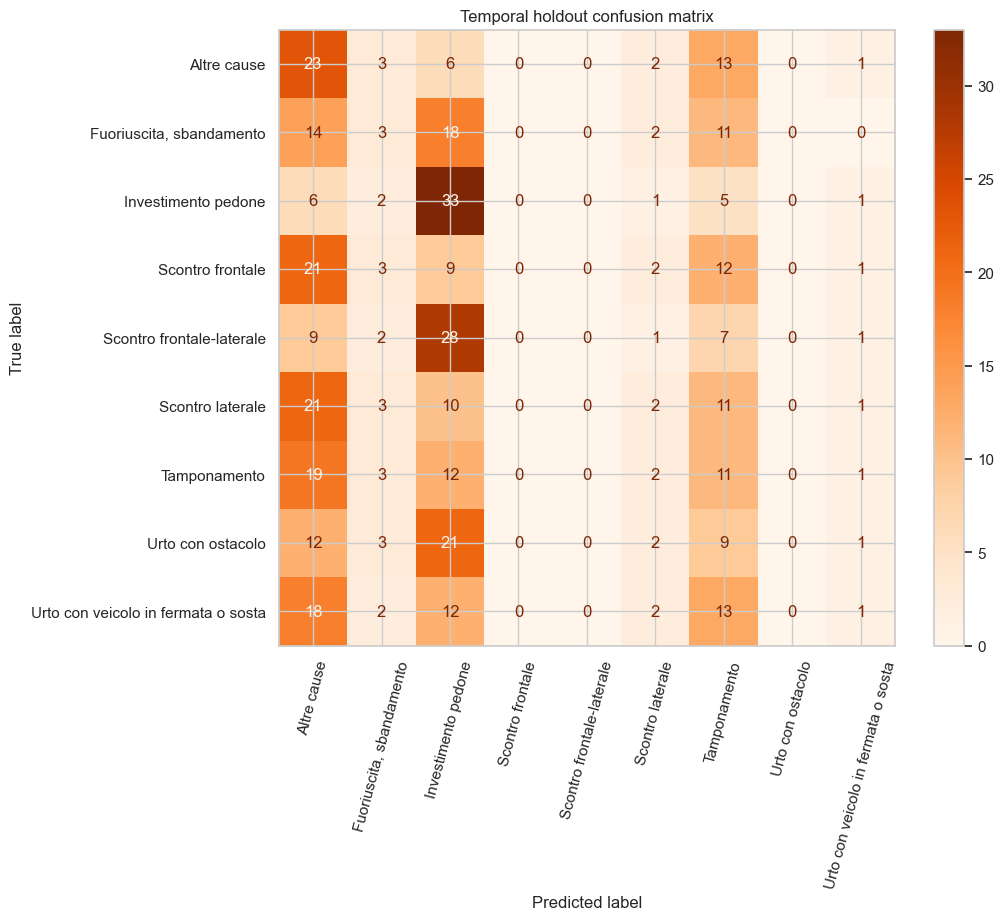

In [11]:
year_cutoff = int(model_df["year"].quantile(0.80))
time_train_mask = model_df["year"] <= year_cutoff

X_time_train = selected_X.loc[time_train_mask]
y_time_train = y.loc[time_train_mask]
X_time_test = selected_X.loc[~time_train_mask]
y_time_test = y.loc[~time_train_mask]

time_model = selected_model
if len(X_time_test) == 0 or y_time_test.nunique() < 2:
    print("Temporal holdout could not be computed because the holdout window is too small.")
else:
    time_model.fit(X_time_train, y_time_train)
    y_time_pred = time_model.predict(X_time_test)

    print(f"Train years <= {year_cutoff}, holdout years > {year_cutoff}")
    print("Temporal holdout classification report:")
    print(classification_report(y_time_test, y_time_pred, zero_division=0))

    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(y_time_test, y_time_pred, xticks_rotation=75, cmap="Oranges", ax=ax)
    ax.set_title("Temporal holdout confusion matrix")
    plt.show()

<!-- auto-explainer:v1 -->

### Interpretation: temporal holdout validation

Random k-fold CV (above) is too optimistic for time-indexed data
because future information leaks into the training fold. This cell
enforces a **temporal holdout**:

- `year_cutoff` = 80th percentile of the observed years.
- Training set: years ≤ cutoff.
- Test set: years > cutoff.

We refit the selected specification on the training slice and
predict the holdout years. The classification report on the holdout
gives the **honest** out-of-period performance. If macro-F1 here is
much lower than in random CV (it typically is), the interpretation
is that crash-type composition drifts over time and the current
feature set does not fully capture that drift.

The orange confusion matrix localizes the failure modes: classes
with near-zero recall on the holdout are the ones whose prevalence
or context changed materially after the cutoff year. This number,
not the random-CV number, is what we should quote when deciding
whether the classifier is fit for forecasting.


### Interpretation Notes

- Significance is controlled with Benjamini-Hochberg correction.
- Robust correlation findings require all three conditions:
  1. corrected partial-correlation significance,
  2. significance after first-difference detrending,
  3. minimum effect-size threshold.
- Rate-model findings are interpreted as incidence-rate ratios relative to the reference crash type.
- Associations are observational and should not be interpreted as direct causal effects.